<a href="https://colab.research.google.com/github/Thanni914/5004-PROJECT-BIG-DATA/blob/main/work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!pip install "dask[complete]"

In [31]:
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import time
from dask.distributed import Client


big_dataset = dd.read_csv('/content/drive/MyDrive/5004CMD_PROJECT/Trips_Full_Data.csv')

small_dataset_dtypes = {
    'County Name': 'object',
    'Number of Trips': 'float64',
    'Number of Trips 1-3': 'float64',
    'Number of Trips 10-25': 'float64',
    'Number of Trips 100-250': 'float64',
    'Number of Trips 25-50': 'float64',
    'Number of Trips 250-500': 'float64',
    'Number of Trips 3-5': 'float64',
    'Number of Trips 5-10': 'float64',
    'Number of Trips 50-100': 'float64',
    'Number of Trips <1': 'float64',
    'Number of Trips >=500': 'float64',
    'Population Not Staying at Home': 'float64',
    'Population Staying at Home': 'float64',
    'State Postal Code': 'object'
}
small_dataset = dd.read_csv('/content/drive/MyDrive/5004CMD_PROJECT/Trips_by_Distance.csv', dtype=small_dataset_dtypes, parse_dates=['Date'])

national_only = big_dataset[big_dataset['Level'] == "National"]


# Removed the line attempting to drop non-existent columns.

print("Data loaded and cleaned successfully BUDDY!")

Data loaded and cleaned successfully BUDDY!


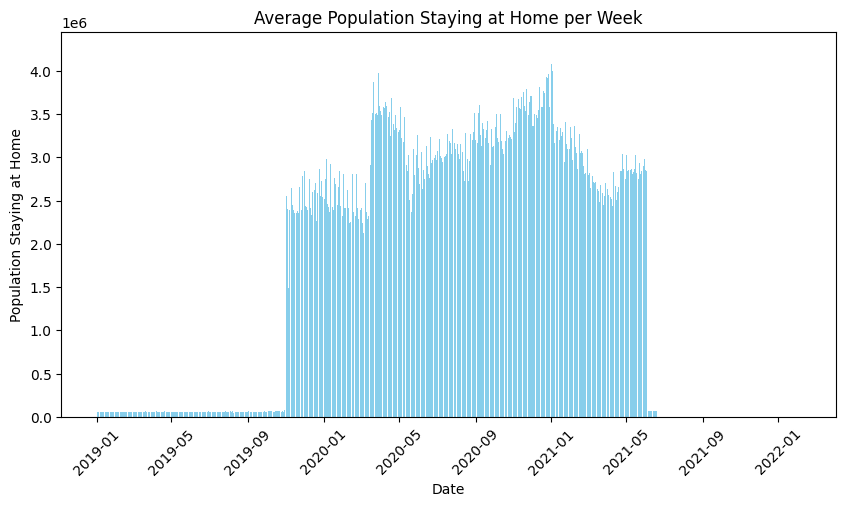

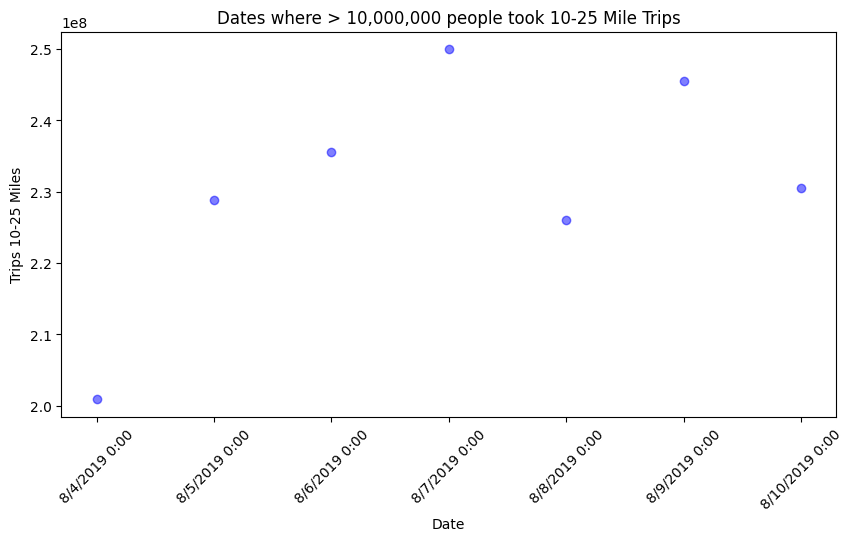

In [35]:
# QUESTION 1: Stay at Home vs Travel. done!!!
start_date = small_dataset['Date'].min().compute()
end_date = small_dataset['Date'].max().compute()

# Only dropping 'Level' as the other specific columns aren't in small_dataset
clean_small = small_dataset.drop(columns=["Level"])

grouped_data = clean_small[['Date', 'Population Staying at Home']].groupby('Date').mean().reset_index().compute()

plt.figure(figsize=(10,5))
plt.bar(grouped_data['Date'], grouped_data['Population Staying at Home'], color='skyblue')
plt.xlabel('Date')
plt.ylabel('Population Staying at Home')
plt.title('Average Population Staying at Home per Week')
plt.xticks(rotation=45)
plt.show()

# --- QUESTION 2: High Frequency Travel Dates. Done!!!

q2_data = national_only[['Trips 10-25 Miles', 'Trips 50-100 Miles', 'Date']]
set1 = q2_data[q2_data['Trips 10-25 Miles'] > 10000000].compute()
set2 = q2_data[q2_data['Trips 50-100 Miles'] > 10000000].compute()

plt.figure(figsize=(10,5))
plt.scatter(set1['Date'], set1['Trips 10-25 Miles'], color='blue', alpha=0.5)
plt.title('Dates where > 10,000,000 people took 10-25 Mile Trips')
plt.xlabel('Date')
plt.ylabel('Trips 10-25 Miles')
plt.xticks(rotation=45)
plt.show()